# Microstrip Arrangment Potential Distribution

## Initialization

In [1]:
# import required libraries
import time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import custom environmnet
from MicroStripArrangementEnv import MicroStripArrangementEnv as msaEnv

# import stable baselines 3
from stable_baselines3 import PPO
# from stable_baselines3 import TD3
# from stable_baselines3 import DDPG
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

## Read True values

In [22]:
df = pd.read_csv('table.csv')
df.drop_duplicates(subset='x',inplace = True, ignore_index=True)
x = np.array(df['x'])
x = x[3:-2]
y = np.array(df['y'])
y = y[3:-2]

## Helping Functions:
* plot function
* predict function

In [3]:
def plot(imgdir,x,y,g_pts,current_energy,i,time):
    # Plot the potential
    fig = plt.figure(figsize=(15,10))
    plt.plot(x,y, color='green', label='True Value')  
    plt.plot(x,g_pts, color='blue', label='Prediction')  
    plt.legend(loc='upper right')
    plt.ylabel('g points')
    plt.xlabel('x')
    plt.grid(True)
    plt.title(f"g points with Energy:{current_energy}, learning time:{time}")
    plt.savefig(f"{imgdir}/PredictionResultfig{i}.png")
    plt.close()

In [4]:
def predict(model,env,x,y,imgdir,i,time):
    # Do the prediction
    obs_space = env.reset()
    action, _states = model.predict(obs_space)
    
    # g_pts
    g_pts = env.e_func(x,action)
    # potential coeffs
    vn = env.potential_coeff(g_pts,x)
    # calculate energy
    current_energy = env.energy(vn)
    # plot
    plot(imgdir,x,y,g_pts,current_energy,i,time)

## Setting up the Environment

In [5]:
env=msaEnv(V0=1,hw_arra=2,ht_arra=2,ht_subs=0.79,hw_micrstr=0.2,ht_micrstr=0,er_1=1,er_2=2.2,num_fs=3000,num_pts=10)
# from stable_baselines3.common.env_checker import check_env
# check_env(env, warn=True)

In [48]:
len(x)

54

## Setting up the model

In [6]:
# create folders to save models and log files
models_dir = "training/models/PPO"
logdir = "training/logs"
imgdir = "training/images"
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    
if not os.path.exists(logdir):
    os.makedirs(logdir)

if not os.path.exists(imgdir):
    os.makedirs(imgdir)
# set the total steps to be taken per learning iteration
TIMESTEPS = 10000

# stop callback
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=100000, verbose=1)
# evaluate and save callback
eval_callback = EvalCallback(env, callback_on_new_best=stop_callback,eval_freq=TIMESTEPS/100, best_model_save_path=models_dir, verbose=1)

# epsilon = 0.2
model = PPO("MlpPolicy", env, verbose=1, tensorboard_log=logdir)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


## Training

In [7]:
for i in range(1,21):
    start_time = time.time()
    model.learn(total_timesteps=TIMESTEPS, callback=eval_callback, reset_num_timesteps=False, tb_log_name="PPO")
    end_time = time.time()
    
    model.save(f"{models_dir}/PPO_MSAEnv_{i*TIMESTEPS}")
    
    # do prediction
    print('predicting')
    predict(model,env,x,y,imgdir,i,end_time-start_time) 

Logging to training/logs\PPO_0
Eval num_timesteps=100, episode_reward=0.00 +/- 0.00
Episode length: 1.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 1        |
|    mean_reward     | 0        |
| time/              |          |
|    total_timesteps | 100      |
---------------------------------


c:\Users\pvmod\anaconda3\envs\pytorch\Lib\site-packages\stable_baselines3\common\evaluation.py:65: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


New best mean reward!
Eval num_timesteps=200, episode_reward=0.00 +/- 0.00
Episode length: 1.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 1        |
|    mean_reward     | 0        |
| time/              |          |
|    total_timesteps | 200      |
---------------------------------
Eval num_timesteps=300, episode_reward=0.00 +/- 0.00
Episode length: 1.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 1        |
|    mean_reward     | 0        |
| time/              |          |
|    total_timesteps | 300      |
---------------------------------
Eval num_timesteps=400, episode_reward=0.00 +/- 0.00
Episode length: 1.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 1        |
|    mean_reward     | 0        |
| time/              |          |
|    total_timesteps | 400      |
---------------------------------
Eval num_timest

In [ ]:
# model.save(f"{models_dir}/PPO_MSAEnv_{i*TIMESTEPS}")

In [40]:
df = pd.read_csv('table.csv')
df.drop_duplicates(subset='x',inplace = True, ignore_index=True)
x = np.array(df['x'])
x = x[3:-2]
y = np.array(df['y'])
y = y[3:-2]

In [11]:
# env=msaEnv(V0=1,hw_arra=2,ht_arra=2,ht_subs=0.79,hw_micrstr=0.2,ht_micrstr=0,er_1=1,er_2=2.2,num_fs=3000,num_pts=10)
env = msaEnv(V0=1,hw_arra=1.38,ht_arra=2.76,ht_subs=0.1382,hw_micrstr=0.05,ht_micrstr=0,er_1=1.0,er_2=12.9,num_fs=1500,num_pts=53)
x = np.linspace(env.hw_micrstr,env.hw_arra,53)
x = x[1:-1]

In [12]:

model = PPO.load("training\models\PPO\PPO_MSAEnv_200000.zip")
obs = env.reset()
g_pts = env.e_func(x,model.predict(obs))

c:\Users\pvmod\anaconda3\envs\pytorch\Lib\site-packages\stable_baselines3\common\save_util.py:166: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
c:\Users\pvmod\anaconda3\envs\pytorch\Lib\site-packages\stable_baselines3\common\save_util.py:166: UserWarning: Could not deserialize object clip_range. Consider using `custom_objects` argument to replace this object.
Exception: code() argument 13 must be str, not int
  warnings.warn(
c:\Users\pvmod\anaconda3\envs\pytorch\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:95: UserWarning: You loaded a model that was trained using OpenAI Gym. We strongly recommend transitioning to Gymnasium by saving that model again.
  warnings.warn(


In [13]:
x = np.insert(x,0,env.hw_micrstr)
x = np.insert(x,0,0)
x = np.append(x,env.hw_arra)

# y = np.insert(y,0,1)
# y = np.insert(y,0,1)
# y = np.append(y,0)

g_pts = np.insert(g_pts,0,1)
g_pts = np.insert(g_pts,0,1)
g_pts = np.append(g_pts,0)

In [14]:
df_method2 = pd.DataFrame({
    'g_ptsx': x/1000,
    'g_ptsy': g_pts
})
df_method2

,g_ptsx,g_ptsy
0,0.000000,1.000000
1,0.000050,1.000000
2,0.000076,0.897860
3,0.000101,0.806153
4,0.000127,0.723813
5,0.000152,0.649883
6,0.000178,0.583504
7,0.000203,0.523905
8,0.000229,0.470393
9,0.000255,0.422347


In [16]:
df_method2.to_csv('Method2_prediction_TestCase2_1.csv')

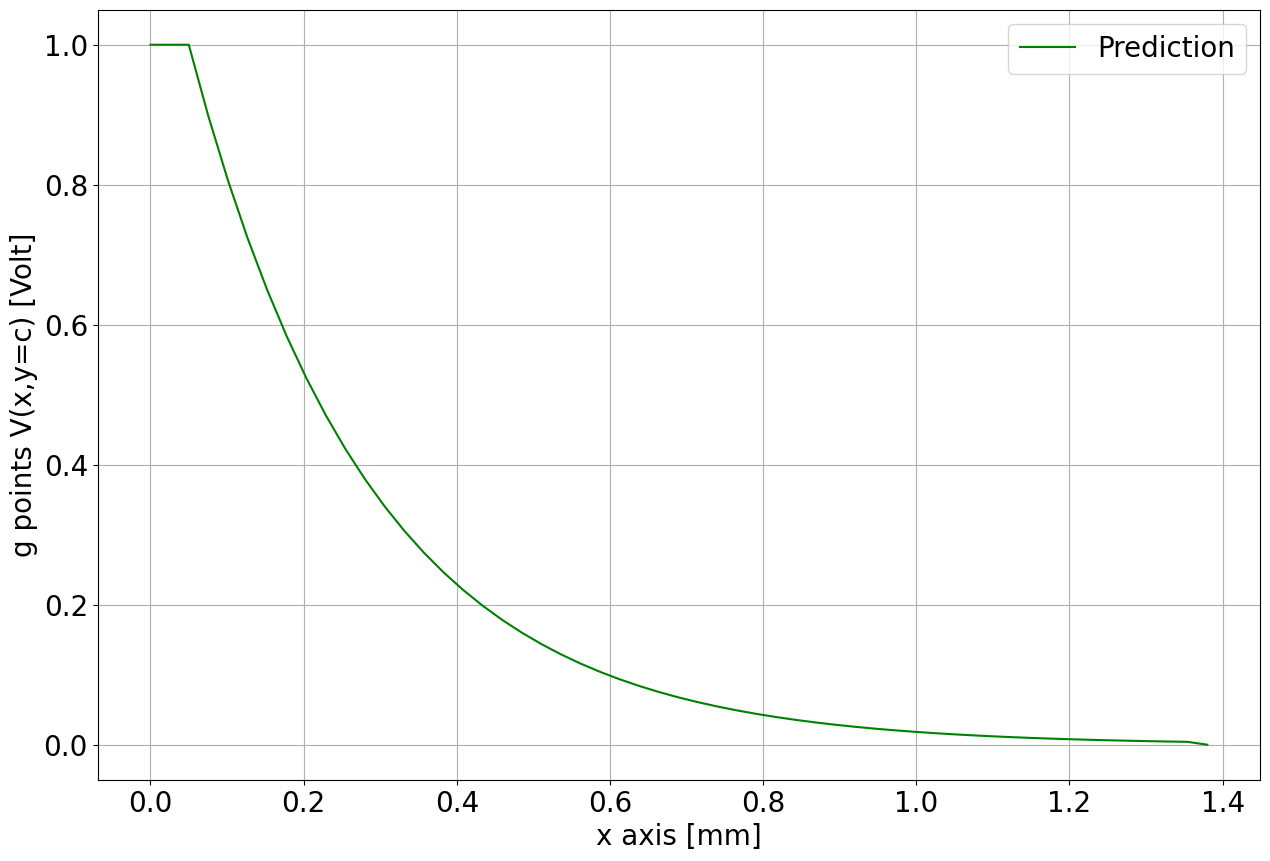

In [15]:
fig = plt.figure(figsize=(15,10))
# plt.plot(x,y, color='blue', label='Nominal')  
plt.plot(x,g_pts, color='green', label='Prediction')  
plt.legend(loc='upper right',fontsize=20)
plt.ylabel('g points V(x,y=c) [Volt]',fontsize=20)
plt.xlabel('x axis [mm]',fontsize=20)

# Set ticks and labels
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

plt.grid(True)
plt.show()

In [44]:
vn = env.potential_coeff(g_pts[2:-1],x[2:-1])
# calculate energy
current_energy = env.energy(vn)

vn = env.potential_coeff(y[2:-1],x[2:-1])
# calculate energy
nominal_energy = env.energy(vn)

In [45]:
current_energy

mpf('1.9623154541462161e-11')

In [46]:
nominal_energy

mpf('1.8531215737851701e-11')

In [50]:
PPO_res = {'g_ptsx':x,
           'g_ptsy':g_pts
           }
(pd.DataFrame(PPO_res)).to_csv(f'g_pts_prediction.csv')